In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("netflix_titles.csv")

df.head()

pd.__version__

'2.3.3'

In [3]:
df.shape


(8807, 12)

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
(df.isnull().mean() * 100).sort_values(ascending=False)

director        29.908028
country          9.435676
cast             9.367549
date_added       0.113546
rating           0.045418
duration         0.034064
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64

In [8]:
resumen_nulls = pd.DataFrame({
    "total_filas": len(df),
    "no_null": df.count(),
    "nulls": df.isnull().sum(),
    "porcentaje_null": (df.isnull().mean() * 100).round(2)
})

resumen_nulls.sort_values("porcentaje_null", ascending=False)


,total_filas,no_null,nulls,porcentaje_null
director,8807,6173,2634,29.91
country,8807,7976,831,9.44
cast,8807,7982,825,9.37
date_added,8807,8797,10,0.11
rating,8807,8803,4,0.05
duration,8807,8804,3,0.03
show_id,8807,8807,0,0.00
type,8807,8807,0,0.00
title,8807,8807,0,0.00
release_year,8807,8807,0,0.00


In [9]:
total = len(df)
cast_nulls = df["cast"].isna().sum()
cast_pct = (cast_nulls / total) * 100

print(f"Total filas: {total}")
print(f"cast nulos: {cast_nulls} ({cast_pct:.2f}%)")


df["cast_missing"] = df["cast"].isna()

df_cast = df.loc[~df["cast_missing"]].copy()

print(f"Filas disponibles para análisis de cast: {len(df_cast)}")


display(df.loc[df["cast_missing"], ["show_id", "type", "title", "country", "release_year"]].head(10))
display(df_cast[["show_id", "type", "title", "cast", "country", "release_year"]].head(5))


Total filas: 8807
cast nulos: 825 (9.37%)
Filas disponibles para análisis de cast: 7982


,show_id,type,title,country,release_year
0,s1,Movie,Dick Johnson Is Dead,United States,2020
3,s4,TV Show,Jailbirds New Orleans,NaN,2021
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,2021
14,s15,TV Show,Crime Stories: India Detectives,NaN,2021
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,NaN,2020
20,s21,TV Show,Monsters Inside: The 24 Faces of Billy Milligan,NaN,2021
45,s46,Movie,My Heroes Were Cowboys,NaN,2021
66,s67,TV Show,Raja Rasoi Aur Anya Kahaniyan,India,2014
69,s70,TV Show,Stories by Rabindranath Tagore,India,2015
74,s75,TV Show,The World's Most Amazing Vacation Rentals,NaN,2021


,show_id,type,title,cast,country,release_year
1,s2,TV Show,Blood & Water,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021
2,s3,TV Show,Ganglands,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021
4,s5,TV Show,Kota Factory,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021
5,s6,TV Show,Midnight Mass,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021
6,s7,Movie,My Little Pony: A New Generation,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021


In [10]:
nulls_por_anio = (
    df.groupby("release_year")["cast_missing"]
      .sum()
      .reset_index(name="cast_nulls")
)


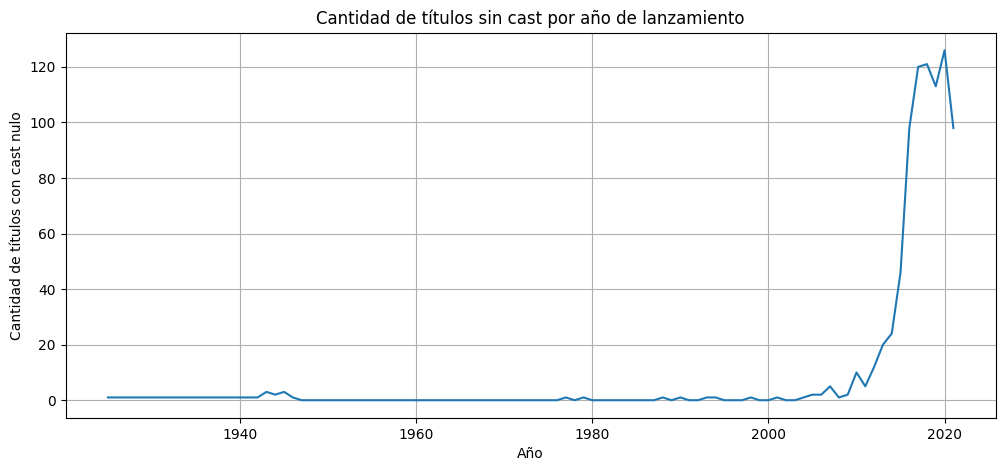

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(
    nulls_por_anio["release_year"],
    nulls_por_anio["cast_nulls"]
)
plt.title("Cantidad de títulos sin cast por año de lanzamiento")
plt.xlabel("Año")
plt.ylabel("Cantidad de títulos con cast nulo")
plt.grid(True)
plt.show()





In [12]:
#hacemos una copia para eliminar los paises que estes separados por ","

df_countries = df.copy()

df_countries["country"] = df_countries["country"].fillna("Unknown")
df_countries["country"] = df_countries["country"].str.split(",")
df_countries = df_countries.explode("country")

In [13]:
df["country_clean"] = df["country"].fillna("Unknown")
df["country_clean"] = df["country_clean"].str.split(",")

df_exploded = df.explode("country_clean")
df_exploded["country_clean"] = df_exploded["country_clean"].str.strip()

df_cast_nulls = df_exploded[df_exploded["cast"].isna()]
nulls_por_pais = (
    df_cast_nulls
    .groupby("country_clean")
    .size()
    .reset_index(name="cast_null")
    .sort_values("cast_null", ascending=False)
)
nulls_por_pais.head(10)


,country_clean,cast_null
58,United States,407
59,Unknown,154
57,United Kingdom,97
20,India,39
16,France,32
8,Canada,31
51,Spain,23
18,Germany,19
3,Australia,17
31,Mexico,16


### Observación

El análisis muestra que algunos países presentan una mayor cantidad de títulos sin información disponible en la columna **cast**, destacándose principalmente Estados Unidos.

Sin embargo, este resultado no necesariamente representa una característica del contenido del catálogo, sino más bien una **limitación en la completitud del dataset**.

Por esta razón, este análisis se considera principalmente como una **revisión de calidad de datos**, y no como un indicador relevante para el comportamiento del catálogo de Netflix.

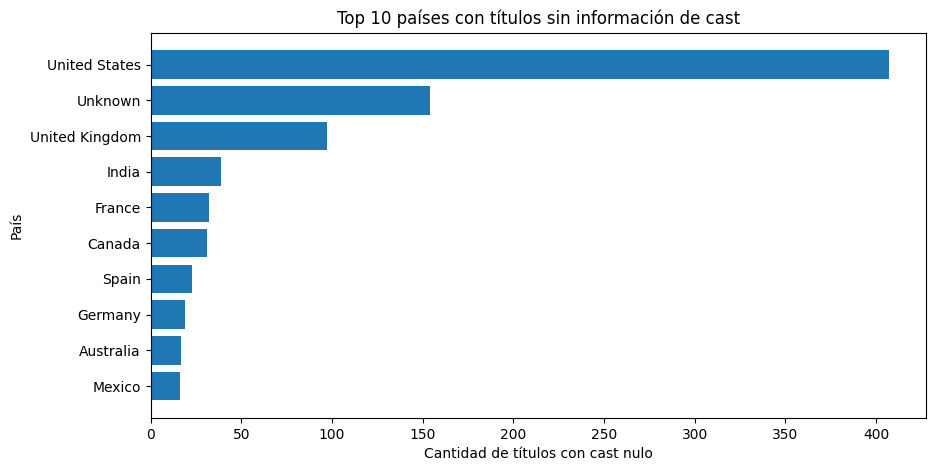

In [14]:
top_paises = nulls_por_pais.head(10)

plt.figure(figsize=(10,5))
plt.barh(top_paises["country_clean"], top_paises["cast_null"])
plt.xlabel("Cantidad de títulos con cast nulo")
plt.ylabel("País")
plt.title("Top 10 países con títulos sin información de cast")
plt.gca().invert_yaxis()
plt.show()


In [15]:
# Copia limpia de country
df["country_clean"] = df["country"].fillna("Unknown").str.split(",")

# Expandir países
df_exploded = df.explode("country_clean")
df_exploded["country_clean"] = df_exploded["country_clean"].str.strip()

# Flag de cast nulo
df_exploded["cast_missing"] = df_exploded["cast"].isna()




In [16]:
nulls_year_country = (
    df_exploded[df_exploded["cast_missing"]]
    .groupby(["release_year", "country_clean"])
    .size()
    .reset_index(name="cast_nulls")
)

nulls_year_country.head()


,release_year,country_clean,cast_nulls
0,1925,Unknown,1
1,1942,United States,1
2,1943,United States,3
3,1944,United States,2
4,1945,United States,3


In [17]:
nulls_year_country = nulls_year_country.query("release_year >= 2000")


## Exploración de valores faltantes (cast)

Durante el análisis exploratorio se identificó que la columna **cast** presenta valores nulos
que no deben ser eliminados ni imputados artificialmente, ya que representan información
categórica no recuperable (nombres propios de actores).

En lugar de eliminar estos registros, los valores nulos se analizan como una **señal de calidad
y completitud del dato**, permitiendo:

- Identificar periodos de tiempo con mayor ausencia de información.
- Analizar diferencias entre países productores.
- Evaluar cambios en la calidad del catálogo de Netflix a lo largo del tiempo.

Este enfoque preserva la integridad del dataset y permite análisis más realistas y trazables.


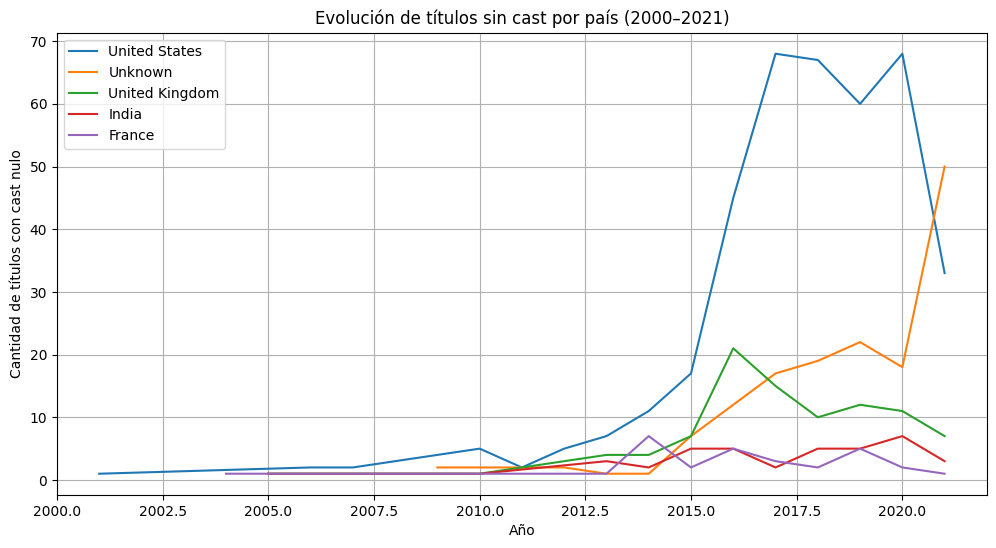

In [18]:
top_countries = (
    nulls_year_country.groupby("country_clean")["cast_nulls"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plot_data = nulls_year_country[
    nulls_year_country["country_clean"].isin(top_countries)
]

plt.figure(figsize=(12,6))

for country in top_countries:
    subset = plot_data[plot_data["country_clean"] == country]
    plt.plot(subset["release_year"], subset["cast_nulls"], label=country)

plt.title("Evolución de títulos sin cast por país (2000–2021)")
plt.xlabel("Año")
plt.ylabel("Cantidad de títulos con cast nulo")
plt.legend()
plt.grid(True)
plt.show()


## Distribución de contenido en Netflix (Movies vs TV Shows)

El catálogo de Netflix incluye dos tipos principales de contenido: **películas (Movies)** y **series o programas de televisión (TV Shows)**.  
Este análisis permite entender la composición general del catálogo disponible en la plataforma.

Analizar la proporción entre películas y series ayuda a identificar la estrategia de contenido de Netflix y cómo se distribuyen los diferentes formatos dentro del catálogo.

**Objetivo del análisis**

- Identificar qué tipo de contenido predomina en el catálogo.
- Comprender la distribución general entre películas y series.
- Detectar posibles tendencias en la oferta de contenido.

Este gráfico muestra la distribución total de títulos disponibles según su tipo de contenido.

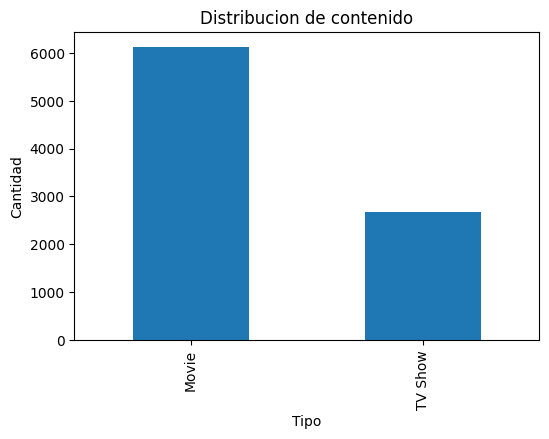

In [19]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(6,4))
type_counts.plot(kind="bar")
plt.title("Distribucion de contenido")
plt.xlabel("Tipo")
plt.ylabel("Cantidad")
plt.show()


## Evolución del número de títulos por año

Uno de los aspectos clave para entender el crecimiento del catálogo de Netflix es analizar cómo ha evolucionado el número de títulos a lo largo del tiempo.

Este análisis permite observar si el contenido disponible ha aumentado, disminuido o se ha mantenido estable durante los diferentes años de producción.

**Objetivo del análisis**

- Identificar periodos de mayor crecimiento del catálogo.
- Detectar cambios en la producción o adquisición de contenido.
- Analizar la expansión del catálogo a lo largo del tiempo.

El siguiente gráfico muestra la cantidad de títulos disponibles en el dataset agrupados por **año de lanzamiento**.

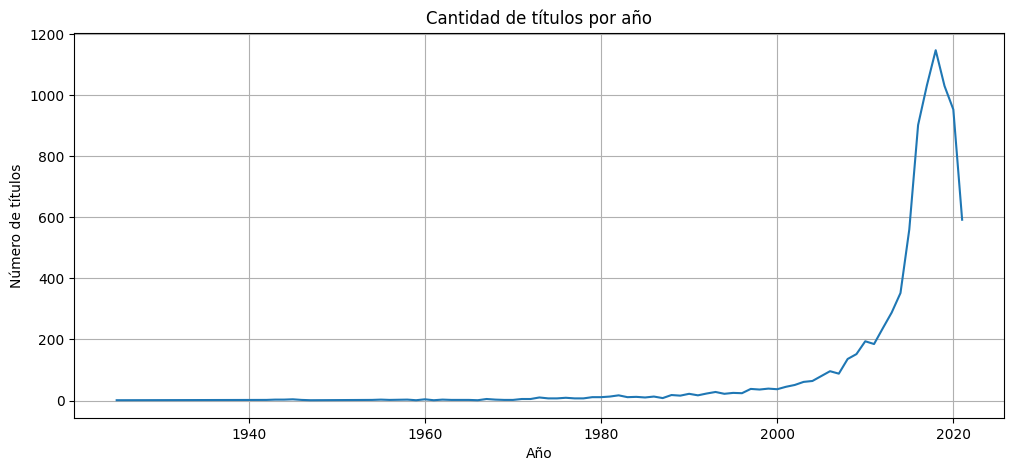

In [20]:
titles_year = df.groupby("release_year").size()

plt.figure(figsize=(12,5))
plt.plot(titles_year.index, titles_year.values)
plt.title("Cantidad de títulos por año")
plt.xlabel("Año")
plt.ylabel("Número de títulos")
plt.grid(True)
plt.show()

In [21]:
df["country_clean"] = df["country"].fillna("Unknown").str.split(",")

df_exploded = df.explode("country_clean")

df_exploded["country_clean"] = df_exploded["country_clean"].str.strip()

### Preparación de los datos

La columna **country** contiene, en algunos casos, múltiples países separados por comas dentro de una misma celda.  
Este formato dificulta el análisis directo de la distribución geográfica del contenido, ya que un mismo registro puede estar asociado a más de un país productor.

Para realizar un análisis más preciso, se aplicaron los siguientes pasos de limpieza y transformación:

- **Rellenar valores faltantes** con la etiqueta `"Unknown"` para evitar pérdidas de información durante el análisis.
- **Separar los países contenidos en una misma celda** utilizando `split(",")`.
- **Expandir cada país en una fila independiente** mediante `explode()`, permitiendo contabilizar correctamente la frecuencia de cada país.
- **Eliminar espacios adicionales** con `strip()` para estandarizar los nombres de los países.

Este proceso permite analizar correctamente la **distribución real de países productores en el catálogo de Netflix**.

In [22]:
df["country_clean"] = df["country"].fillna("Unknown").str.split(",")
df_exploded = df.explode("country_clean")

df_exploded["country_clean"] = df_exploded["country_clean"].str.strip()

top_countries = df_exploded["country_clean"].value_counts().head(10)


## Países con mayor presencia en el catálogo de Netflix

El contenido disponible en Netflix proviene de diferentes países alrededor del mundo.  
Analizar la distribución geográfica del contenido permite identificar qué industrias audiovisuales tienen mayor presencia dentro del catálogo.

Dado que algunos títulos pueden estar asociados a múltiples países, fue necesario **separar los países contenidos en una misma celda** para analizar correctamente su frecuencia.

**Objetivo del análisis**

- Identificar los países con mayor producción o presencia en el catálogo.
- Analizar la diversidad geográfica del contenido disponible.
- Detectar posibles concentraciones de producción audiovisual.

El siguiente gráfico muestra los **10 países con mayor número de títulos en el catálogo de Netflix**.

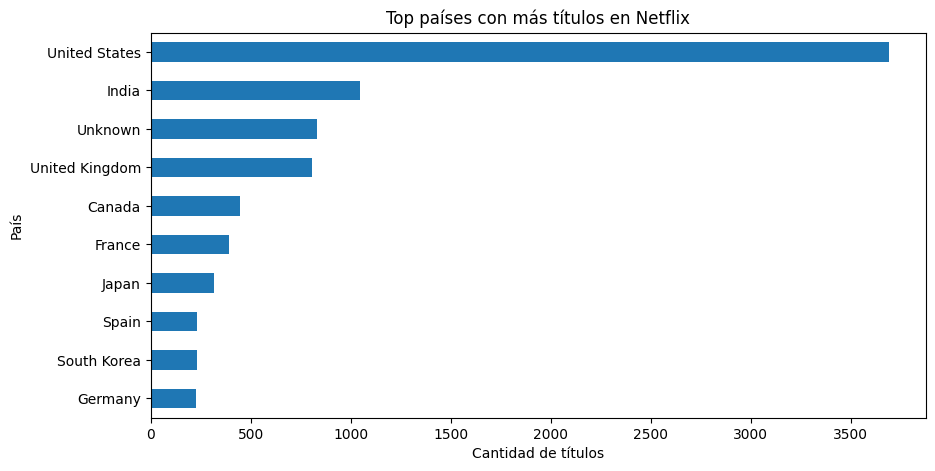

In [23]:
plt.figure(figsize=(10,5))
top_countries.plot(kind="barh")

plt.title("Top países con más títulos en Netflix")
plt.xlabel("Cantidad de títulos")
plt.ylabel("País")

plt.gca().invert_yaxis()
plt.show()

In [25]:
df.to_csv("netflix_clean.csv", index=False)